<a href="https://colab.research.google.com/github/Alaaeldinaly/Clean-data25/blob/main/Clean_data25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import pickle

In [28]:
file_path = "cleaned_data.csv"   # uploaded file
df = pd.read_csv(file_path)

In [29]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-zA-Z0-9_]", "", regex=True)
)


In [30]:
date_cols = [col for col in df.columns if "date" in col or "time" in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

date_col = date_cols[0] if len(date_cols) > 0 else None
if date_col:
    df = df.sort_values(by=date_col).reset_index(drop=True)

In [31]:
df = df.drop_duplicates().reset_index(drop=True)


In [33]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [35]:
if date_col and len(numeric_cols) > 0:
    df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")
    df[numeric_cols] = df[numeric_cols].ffill().bfill()

if len(numeric_cols) > 0 and df[numeric_cols].isnull().sum().sum() > 0:
    imputer = KNNImputer(n_neighbors=5)
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")

In [36]:
financial_cols = [col for col in df.columns if any(x in col for x in ["open", "high", "low", "close", "volume"])]
for col in financial_cols:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        df.loc[df[col] < 0, col] = np.nan

if len(numeric_cols) > 0 and df[numeric_cols].isnull().sum().sum() > 0:
    df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")
    df[numeric_cols] = df[numeric_cols].ffill().bfill()

if set(["high", "low"]).issubset(df.columns):
    swap_mask = df["high"] < df["low"]
    df.loc[swap_mask, ["high", "low"]] = df.loc[swap_mask, ["low", "high"]].values

In [37]:
for col in ["close", "volume"]:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = np.clip(df[col], lower, upper)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    iso = IsolationForest(contamination=0.02, random_state=42)
    df["anomaly_flag"] = iso.fit_predict(df[numeric_cols])
else:
    df["anomaly_flag"] = 1

In [38]:
if "close" in df.columns:
    df["return_1d"] = df["close"].pct_change()
    df["log_return_1d"] = np.log(df["close"] / df["close"].shift(1))
    df["ma_5"] = df["close"].rolling(5).mean()
    df["ma_10"] = df["close"].rolling(10).mean()
    df["ma_20"] = df["close"].rolling(20).mean()
    df["ema_12"] = df["close"].ewm(span=12, adjust=False).mean()
    df["ema_26"] = df["close"].ewm(span=26, adjust=False).mean()
    df["volatility_5"] = df["return_1d"].rolling(5).std()
    df["volatility_10"] = df["return_1d"].rolling(10).std()

    delta = df["close"].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    df["macd"] = df["ema_12"] - df["ema_26"]
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()

if set(["high", "low"]).issubset(df.columns):
    df["price_range"] = df["high"] - df["low"]

if set(["open", "close"]).issubset(df.columns):
    df["daily_change"] = df["close"] - df["open"]
    df["daily_change_pct"] = (df["close"] - df["open"]) / df["open"]

if "volume" in df.columns:
    df["volume_ma_5"] = df["volume"].rolling(5).mean()
    df["volume_ma_10"] = df["volume"].rolling(10).mean()

if date_col:
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["day"] = df[date_col].dt.day
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["quarter"] = df[date_col].dt.quarter

df = df.ffill().bfill()

In [39]:
if "close" in df.columns:
    df["target_class"] = (df["close"].shift(-1) > df["close"]).astype(int)
    df["target_reg"] = df["close"].shift(-1)
    df = df.iloc[:-1].reset_index(drop=True)

In [47]:
target = "target_class" if "target_class" in df.columns else None

# Initialize X_train, X_val, X_test, y_train, y_val, y_test to prevent NameError
X_train, X_val, X_test = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
y_train, y_val, y_test = pd.Series(), pd.Series(), pd.Series()

if target:
    X = df.drop(columns=["target_class", "target_reg"], errors="ignore")
    y = df[target]

    shuffle_data = False if date_col else True

    # Check if there's enough data to perform a split
    if len(X) > 1 and len(y) > 1:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.30, random_state=42, shuffle=shuffle_data
        )

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, random_state=42, shuffle=shuffle_data
        )
        print("Data split into X_train, X_val, X_test, y_train, y_val, y_test.")
    else:
        print("Not enough data to perform train/test split. X_train, X_val, X_test, y_train, y_val, y_test remain empty.")
else:
    print("Skipping data split as 'target_class' column is not found (likely 'close' column is missing in DataFrame).")

Skipping data split as 'target_class' column is not found (likely 'close' column is missing in DataFrame).


In [48]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [49]:
output_dir = "/mnt/data/project2_outputs"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(f"{output_dir}/cleaned_full_dataset.csv", index=False)
X_train.to_csv(f"{output_dir}/X_train.csv", index=False)
X_val.to_csv(f"{output_dir}/X_val.csv", index=False)
X_test.to_csv(f"{output_dir}/X_test.csv", index=False)

pd.DataFrame({"target": y_train}).to_csv(f"{output_dir}/y_train.csv", index=False)
pd.DataFrame({"target": y_val}).to_csv(f"{output_dir}/y_val.csv", index=False)
pd.DataFrame({"target": y_test}).to_csv(f"{output_dir}/y_test.csv", index=False)

np.save(f"{output_dir}/X_train_processed.npy", X_train_processed)
np.save(f"{output_dir}/X_val_processed.npy", X_val_processed)
np.save(f"{output_dir}/X_test_processed.npy", X_test_processed)

with open(f"{output_dir}/preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

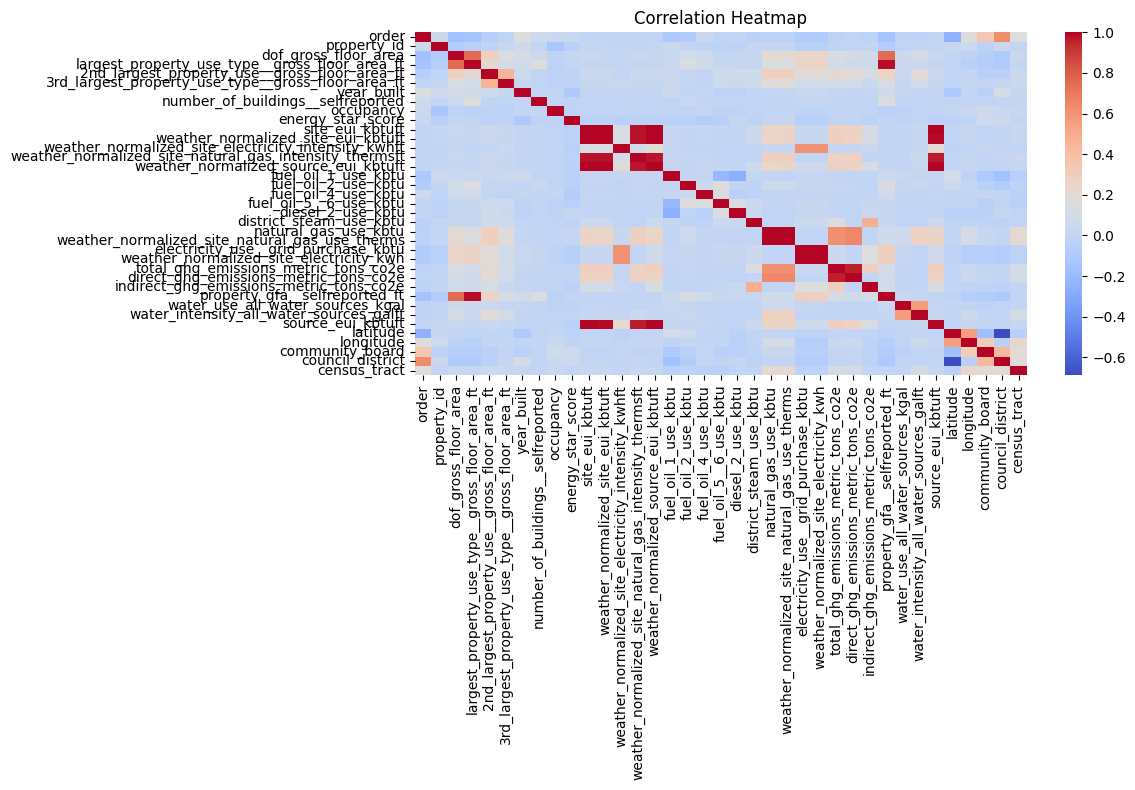

Done. Files saved in: /mnt/data/project2_outputs


In [50]:
if "close" in df.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(df["close"], label="Close")
    if "ma_5" in df.columns:
        plt.plot(df["ma_5"], label="MA 5")
    if "ma_20" in df.columns:
        plt.plot(df["ma_20"], label="MA 20")
    plt.legend()
    plt.title("Close Price and Moving Averages")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/close_moving_averages.png")
    plt.show()

if "return_1d" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df["return_1d"].dropna(), bins=50, kde=True)
    plt.title("Daily Returns Distribution")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/daily_returns_distribution.png")
    plt.show()

if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/correlation_heatmap.png")
    plt.show()

print("Done. Files saved in:", output_dir)